# 합성곱 신경망을 사용한 이미지 분류


## Exp 12 - Average Pooling

- 변경 내용: Baseline의 MaxPooling2D(2)를 AveragePooling2D(2)로 변경한다.
- 실험 목적: pooling 방식 차이가 Fashion-MNIST 분류 성능에 미치는 영향을 확인한다.
- 비교 기준: 동일한 데이터 분할, 동일한 seed, 동일한 최대 epoch 조건을 사용한다.
- 실험 근거: MaxPooling은 강한 특징을 보존하고 AveragePooling은 영역의 평균 정보를 반영하므로, pooling 방식에 따른 특징 보존 방식의 차이를 비교한다.



In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/08-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>


In [2]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()


## 패션 MNIST 데이터 불러오기


In [3]:
import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)


## 합성곱 신경망 만들기


In [4]:
model = keras.Sequential(name='exp12_avg_pooling')
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.AveragePooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.AveragePooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))



In [5]:
model.summary()


Model: "exp15_avg_pooling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 7, 7, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

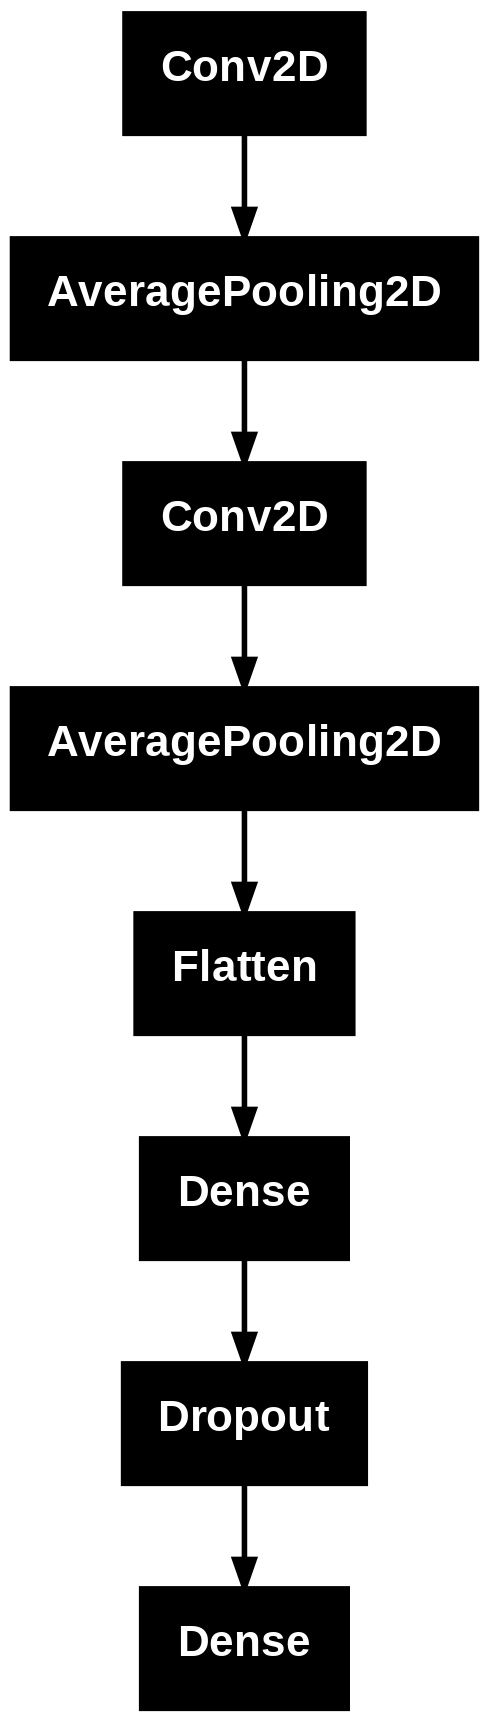

In [6]:
keras.utils.plot_model(model)


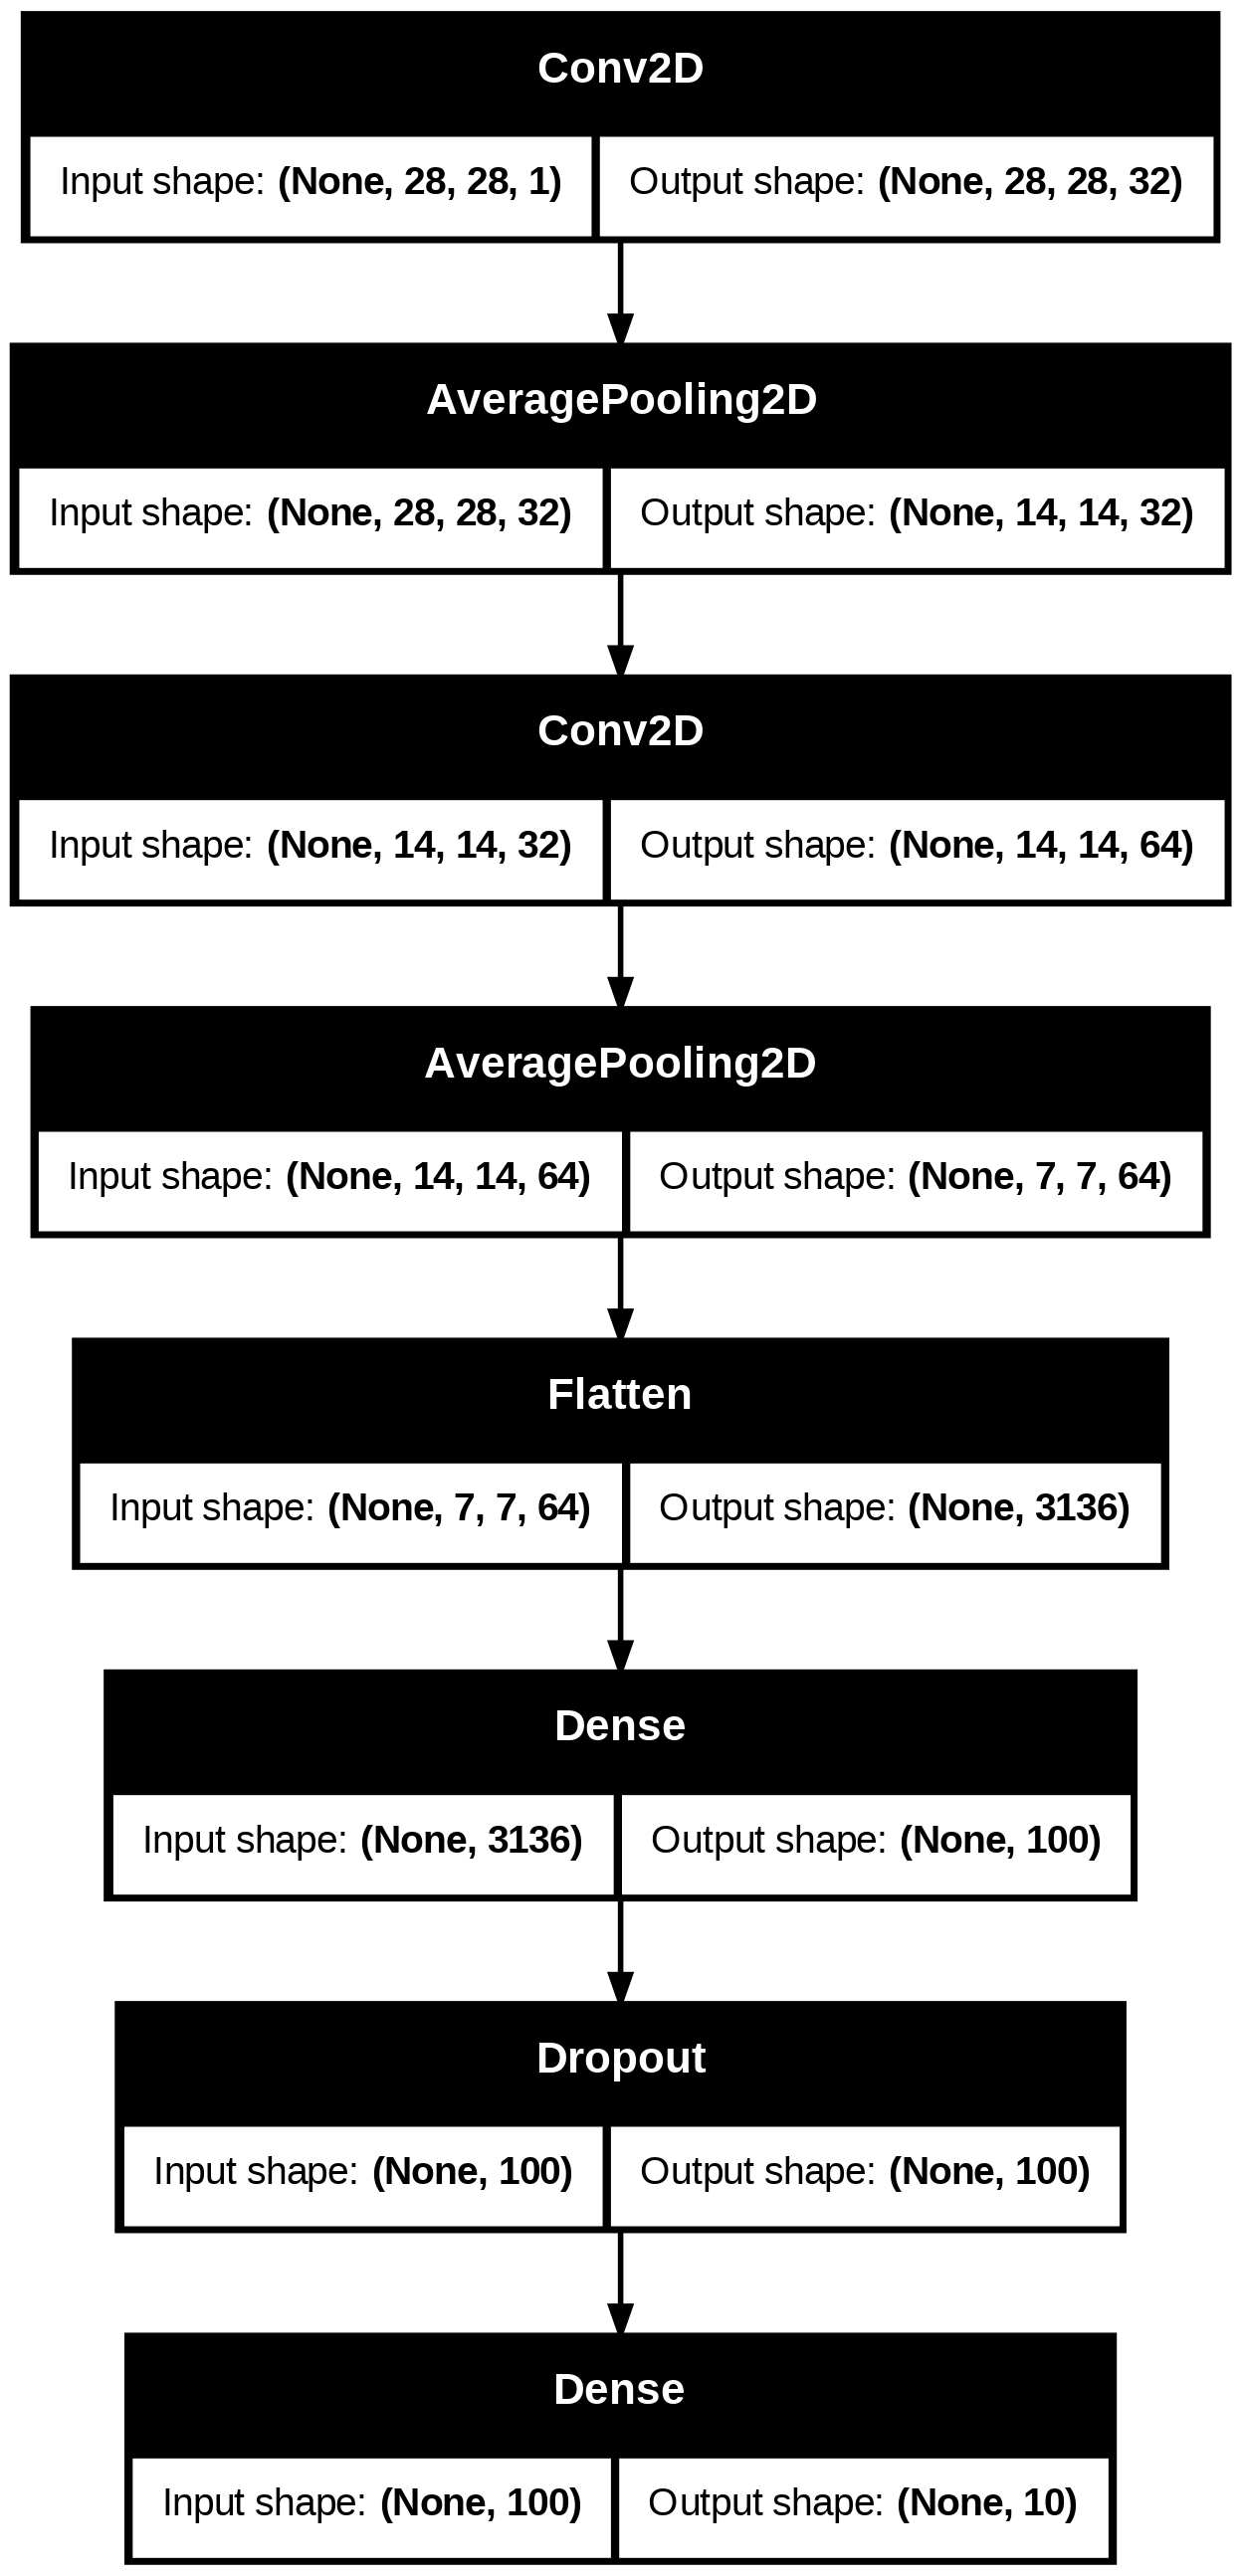

In [7]:
keras.utils.plot_model(model, show_shapes=True)


## 모델 컴파일과 훈련


In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              # 현재 텐서플로 버전에서는 최대 풀링에 대한 결정적인 XLA 구현이 없기 때문에
              # enable_op_determinism() 호출로 인해 오류가 발생합니다.
              # 이를 피하기 위해 jit_compile 옵션을 False로 지정합니다.
              # https://github.com/tensorflow/tensorflow/issues/69417
              jit_compile=False)
checkpoint_cb = keras.callbacks.ModelCheckpoint('12_avg_pooling.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=15,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])




Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.7819 - loss: 0.6034 - val_accuracy: 0.8622 - val_loss: 0.3880
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8516 - loss: 0.4114 - val_accuracy: 0.8785 - val_loss: 0.3242
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8708 - loss: 0.3618 - val_accuracy: 0.8891 - val_loss: 0.2995
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8817 - loss: 0.3256 - val_accuracy: 0.8978 - val_loss: 0.2767
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8917 - loss: 0.3042 - val_accuracy: 0.9032 - val_loss: 0.2614
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8978 - loss: 0.2832 - val_accuracy: 0.9074 - val_loss: 0.2498
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9036 - loss: 0.2637 - val_accuracy: 0.9122 - val_loss: 0.2409
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9099 - loss: 0

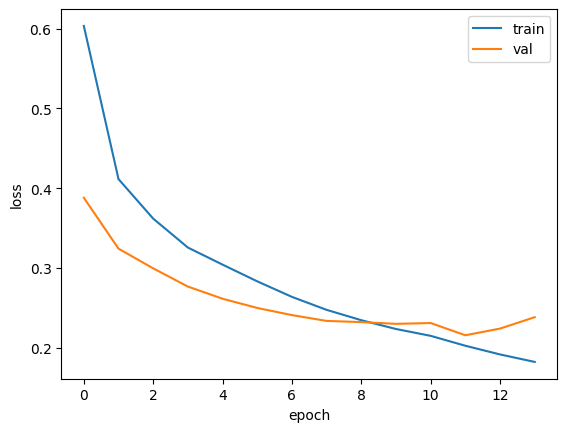

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()


## Accuracy Curve

Train accuracy와 validation accuracy를 비교하여 일반화 성능과 과적합 여부를 확인합니다.



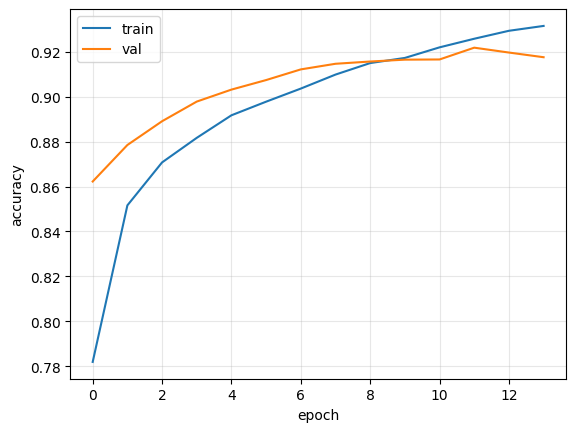

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'val'])
plt.grid(True, alpha=0.3)
plt.show()




In [11]:
model.evaluate(val_scaled, val_target)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9218 - loss: 0.2156


[0.21559560298919678, 0.921833336353302]

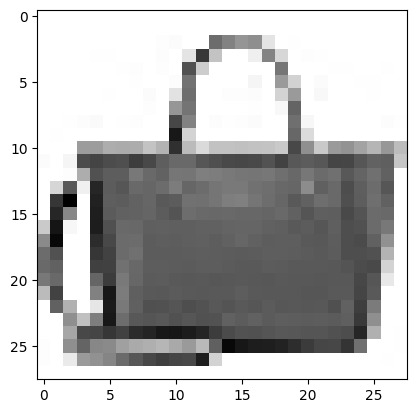

In [12]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()


In [13]:
preds = model.predict(val_scaled[0:1])
print(preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
[[2.8404686e-21 5.4368824e-32 3.1618308e-27 4.5296216e-24 1.0222000e-23
  6.4102263e-23 2.5205576e-23 2.3801906e-21 1.0000000e+00 1.1393209e-22]]


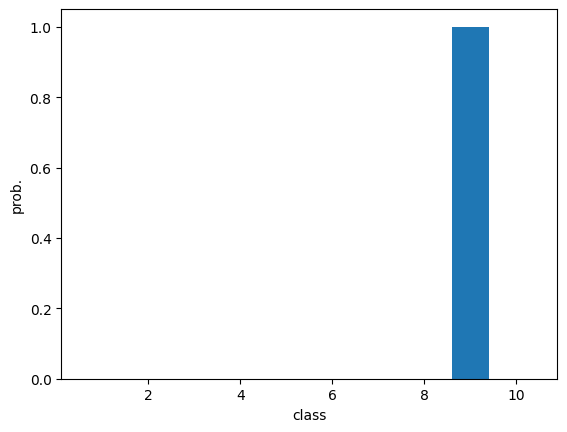

In [14]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()


In [15]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']


In [16]:
import numpy as np

print(classes[np.argmax(preds)])


가방


In [17]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0


In [18]:
model.evaluate(test_scaled, test_target)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9188 - loss: 0.2368


[0.2368195354938507, 0.9187999963760376]

## Confusion Matrix

Test set에서 어떤 class끼리 혼동되는지 확인합니다.



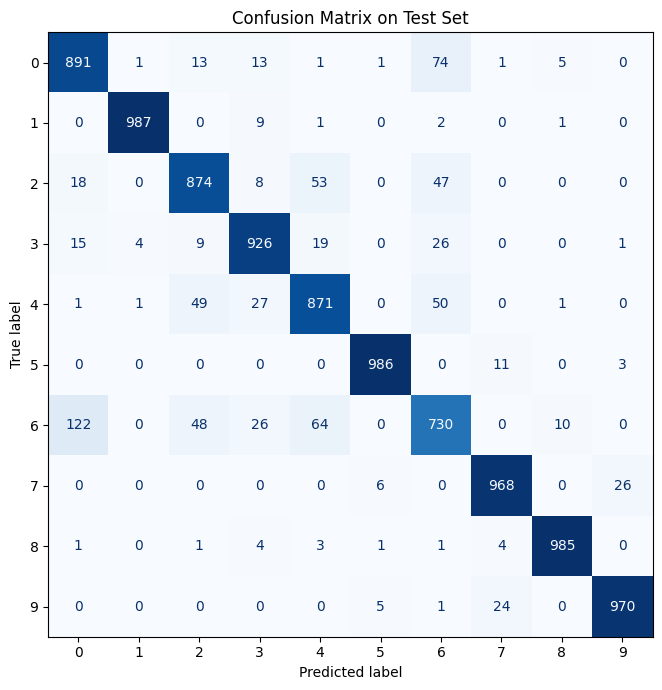

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

pred_labels = model.predict(test_scaled, verbose=0).argmax(axis=1)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    test_target,
    pred_labels,
    display_labels=range(10),
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()




## 실험 결과 저장

집계 노트북에서 비교할 수 있도록 validation/test 성능과 loss history를 JSON 파일로 저장합니다.



In [20]:
import json
import os

val_loss, val_accuracy = model.evaluate(val_scaled, val_target, verbose=0)
test_loss, test_accuracy = model.evaluate(test_scaled, test_target, verbose=0)

try:
    RESULT_DIR = '/content/drive/MyDrive/CNN_fashion_results'
    os.makedirs(RESULT_DIR, exist_ok=True)
except Exception:
    RESULT_DIR = './CNN_fashion_results'
    os.makedirs(RESULT_DIR, exist_ok=True)

result = {
    'experiment_name': model.name,
    'parameter_count': int(model.count_params()),
    'epochs_ran': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'final_val_loss': float(val_loss),
    'final_val_accuracy': float(val_accuracy),
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'train_loss_history': [float(x) for x in history.history['loss']],
    'val_loss_history': [float(x) for x in history.history['val_loss']],
    'train_accuracy_history': [float(x) for x in history.history['accuracy']],
    'val_accuracy_history': [float(x) for x in history.history['val_accuracy']],
}

result_path = os.path.join(RESULT_DIR, f'{model.name}.json')
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print('Saved result:', result_path)
print(result)




Saved result: /content/drive/MyDrive/CNN_fashion_results/exp15_avg_pooling.json
{'experiment_name': 'exp15_avg_pooling', 'parameter_count': 333526, 'epochs_ran': 14, 'best_val_loss': 0.21559560298919678, 'best_val_accuracy': 0.921833336353302, 'final_val_loss': 0.21559560298919678, 'final_val_accuracy': 0.921833336353302, 'test_loss': 0.2368195354938507, 'test_accuracy': 0.9187999963760376, 'train_loss_history': [0.6033935546875, 0.4113558828830719, 0.3618377149105072, 0.3255813419818878, 0.30415061116218567, 0.28320392966270447, 0.26372069120407104, 0.24745528399944305, 0.23448152840137482, 0.2234596312046051, 0.21486958861351013, 0.20245276391506195, 0.1915568858385086, 0.18218688666820526], 'val_loss_history': [0.38799428939819336, 0.324167400598526, 0.2994798719882965, 0.2766526937484741, 0.26140403747558594, 0.24983477592468262, 0.24086755514144897, 0.23359668254852295, 0.23209616541862488, 0.22992537915706635, 0.23092059791088104, 0.21559560298919678, 0.2239927351474762, 0.238265